# 科技板块投资组合分析

对 **AI、半导体、新能源** 三大板块共 **35只股票** 进行端到端量化分析——从原始数据到EDA、风险评估、均值-方差组合优化与回测。

> 数据区间：2025年5月 – 2026年5月（251个交易日）

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
from IPython.display import display, Image
from pathlib import Path
import warnings
warnings.filterwarnings("ignore")

plt.rcParams["figure.dpi"] = 100
pd.set_option("display.max_columns", 20)
pd.set_option("display.width", 120)

DATA = Path("data")
CHART = Path("charts")

## 核心结果

| 组合策略 | 总收益 | 夏普比率 | 最大回撤 | 胜率 |
|---------|:------:|:-------:|:-------:|:----:|
| **最大夏普组合** | **+364.8%** | **4.46** | -13.6% | 63.6% |
| 板块等权组合 | +80.9% | 2.15 | -14.5% | 56.0% |
| 全等权组合 | +75.6% | 2.03 | -15.1% | 56.4% |
| 标普500（基准） | +26.8% | 1.63 | -9.1% | 57.2% |

> 优化后的最大夏普组合在分析期间实现了标普500收益的 **13.6倍**，主要得益于芯片板块优质标的的集中持仓（INTC、MU、GOOGL各占15%上限）。

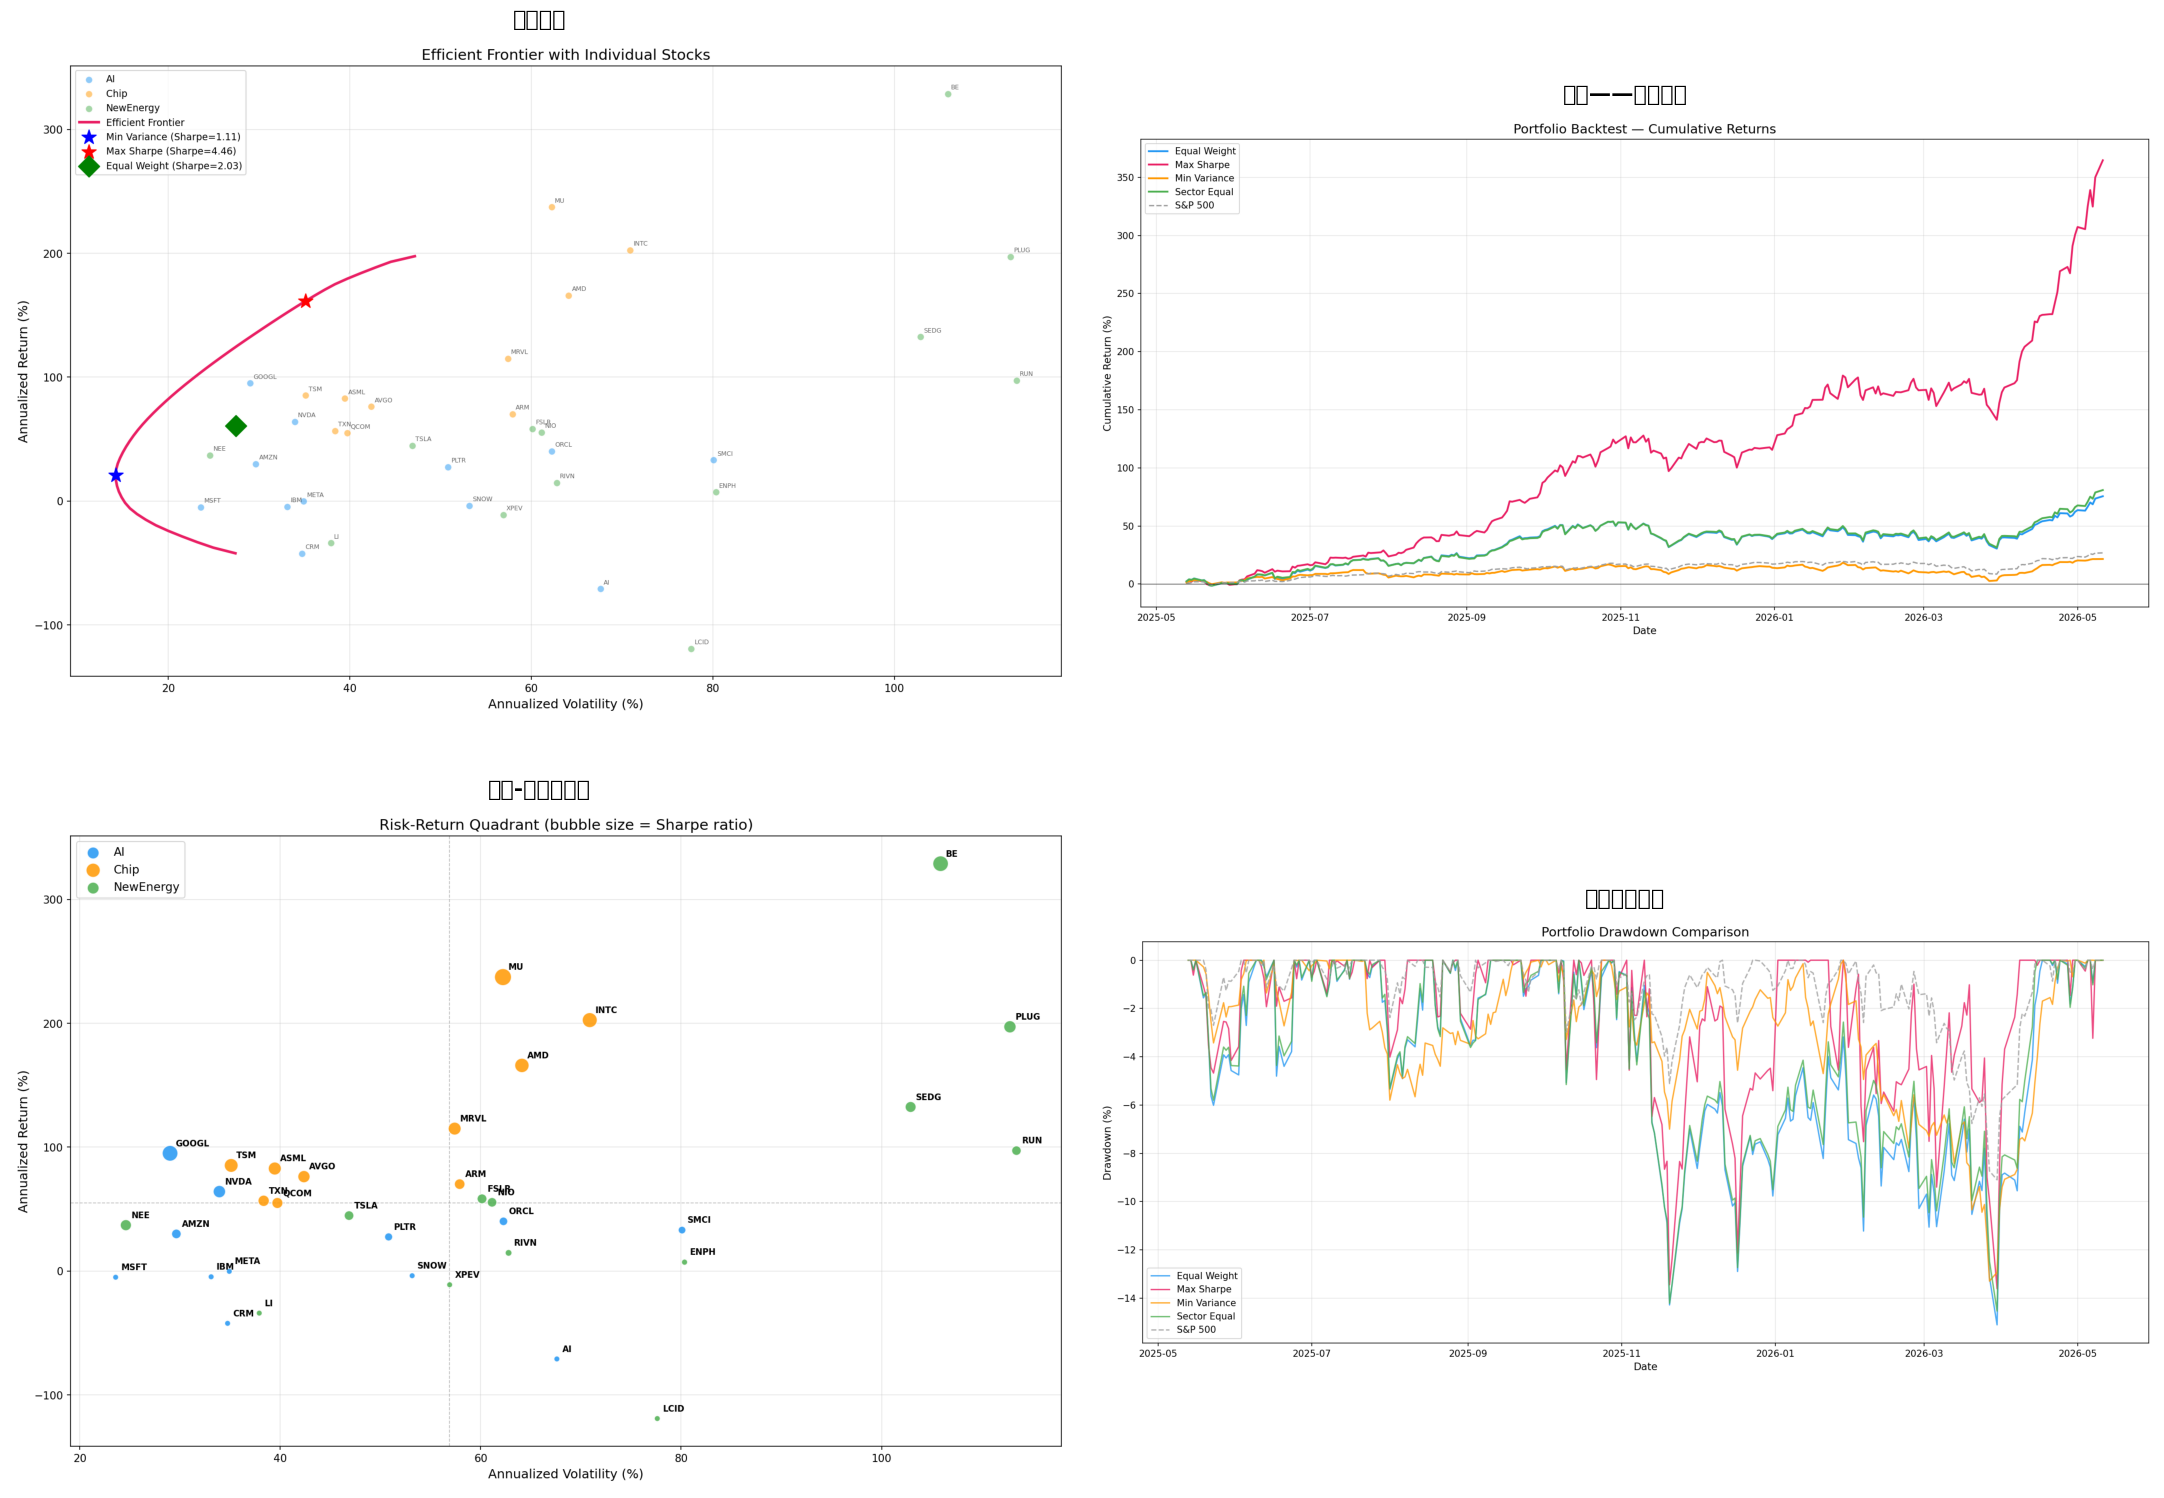

In [2]:
fig, axes = plt.subplots(2, 2, figsize=(22, 16))
charts = [
    (CHART / "Part6_Portfolio/Step12_EfficientFrontier/efficient_frontier.png", "有效前沿"),
    (CHART / "Part6_Portfolio/Step13_Backtest/cumulative_returns.png", "回测——累计收益"),
    (CHART / "Part5_Risk/Step11_RiskMetrics/risk_return_quadrant.png", "风险-收益象限图"),
    (CHART / "Part6_Portfolio/Step13_Backtest/drawdown_comparison.png", "组合回撤对比"),
]
for ax, (path, title) in zip(axes.flat, charts):
    ax.imshow(mpimg.imread(str(path)))
    ax.set_title(title, fontsize=16, fontweight="bold", pad=12)
    ax.axis("off")
plt.tight_layout(pad=2)
plt.show()

---
## 分析流程

```
数据 ── 第一部分:EDA ── 第二部分:波动率 ── 第三部分:相关性 ── 第四部分:领涨领跌
                                                                      │
                       第六部分:组合优化 ◄── 第五部分:风险 ◄──────────┘
```

| 部分 | 脚本 | 步骤 | 说明 |
|------|------|:----:|------|
| 数据 | `download_data.py` | 1 | Yahoo Finance 下载1年日线 OHLCV |
| 第一部分：EDA | `EDA.py` `candlestick.py` `returns.py` | 2–3 | 数据质量、折线图、收益率分布 |
| 第二部分：波动率 | `volatility.py` | 4–5 | 年化波动率、滚动波动率、异常检测 |
| 第三部分：相关性 | `correlation.py` | 6–7 | 跨板块相关性、Beta分析 |
| 第四部分：领涨领跌 | `leadlag.py` | 8–9 | 滞后相关性、领导力评分 |
| 第五部分：风险 | `risk.py` | 10–11 | 回撤、VaR、夏普/索提诺/卡尔马 |
| 第六部分：组合优化 | `portfolio.py` | 12–13 | 有效前沿、组合回测 |

## 股票池

In [3]:
summary = pd.read_csv(DATA / "_summary.csv")
sector_map = {"AI": "AI科技", "Chip": "芯片", "NewEnergy": "新能源", "Index": "指数"}
overview = summary.groupby("Sector").agg(
    Count=("Ticker", "count"),
    Tickers=("Ticker", lambda x: ", ".join(x)),
).rename(index=sector_map)
display(overview)
print(f"\n数据区间: {summary['Start'].iloc[0]} ~ {summary['End'].iloc[0]}  |  每只股票 {summary['Records'].iloc[0]} 个交易日")

,Count,Tickers
Sector,,
AI科技,12,"NVDA, MSFT, GOOGL, META, AMZN, CRM, PLTR, AI, ..."
芯片,10,"AMD, INTC, TSM, AVGO, QCOM, TXN, MU, MRVL, ARM..."
指数,6,"^GSPC, ^IXIC, ^DJI, ^RUT, ^VIX, ^SOX"
新能源,13,"TSLA, ENPH, SEDG, FSLR, RUN, PLUG, BE, NEE, RI..."



数据区间: 2025-05-12 ~ 2026-05-11  |  每只股票 251 个交易日


---
## 第一部分：EDA（探索性数据分析）

### 第1步 — 数据质量检查

9项质量检查全部通过。仅有少量Yahoo数据精度问题（NEE、XPEV各1天开盘价略高于最高价），VIX和SOX全程零成交量（指数正常现象）。

### 第2步 — 表现排名与板块对比

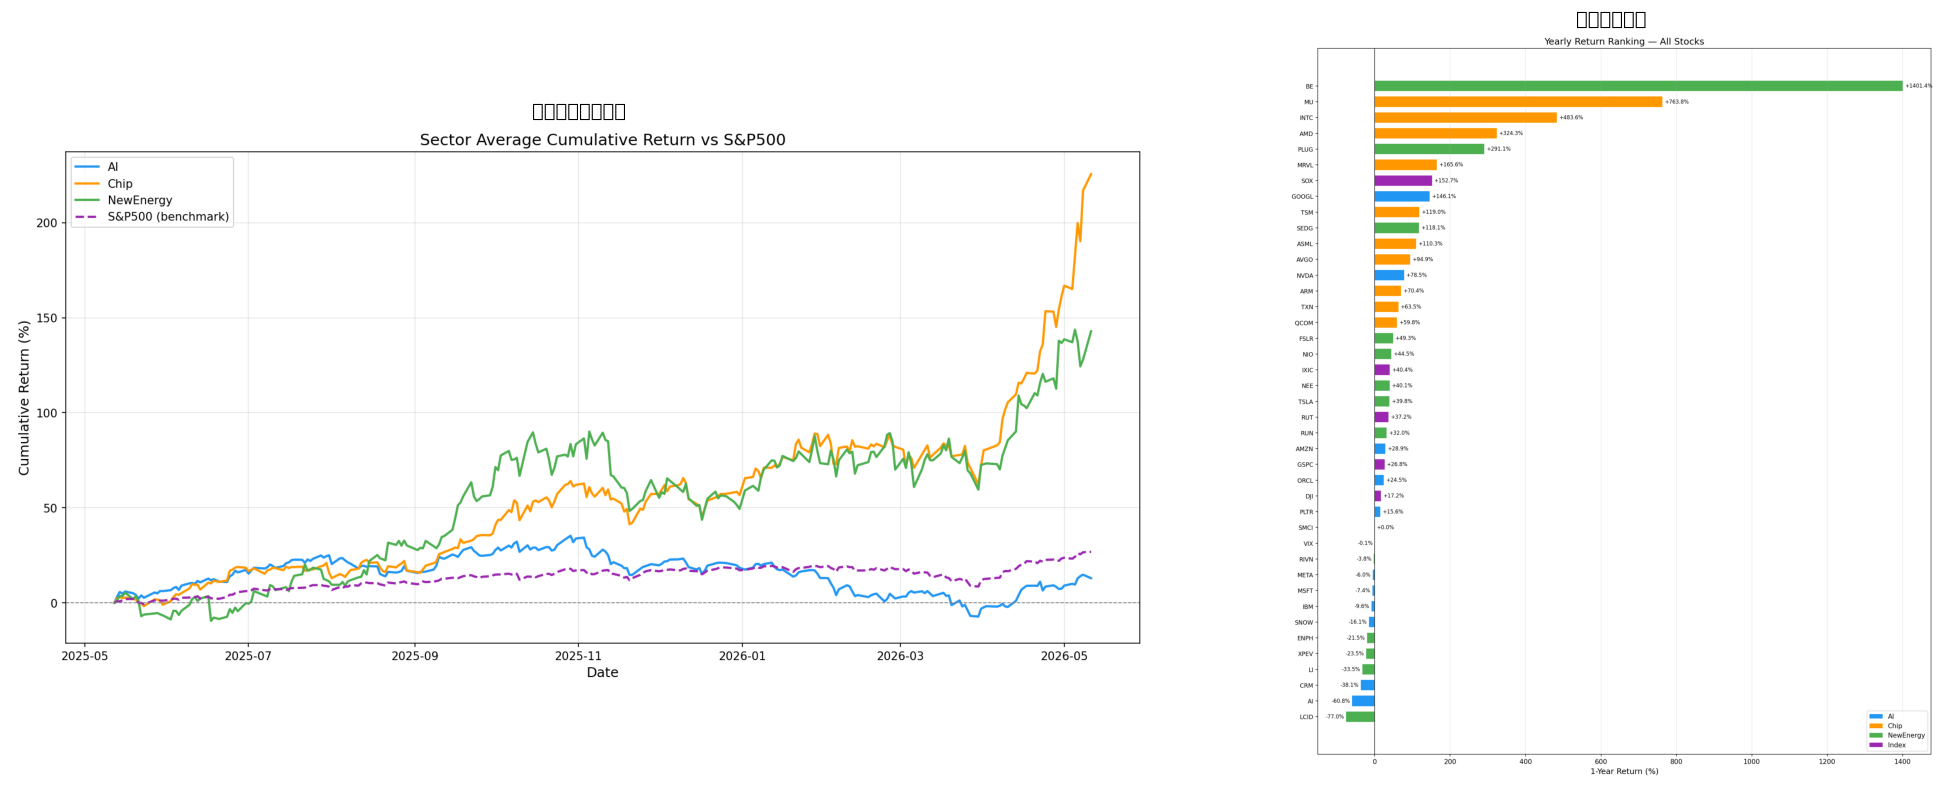

In [4]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(22, 8))
ax1.imshow(mpimg.imread(str(CHART / "Part1_EDA/Step2_LineCharts/sector_cumulative_return.png")))
ax1.set_title("板块累计收益对比", fontsize=14, fontweight="bold")
ax1.axis("off")
ax2.imshow(mpimg.imread(str(CHART / "Part1_EDA/Step3_Returns/yearly_return_ranking.png")))
ax2.set_title("年度收益排名", fontsize=14, fontweight="bold")
ax2.axis("off")
plt.tight_layout()
plt.show()

In [5]:
perf = pd.read_csv(CHART / "Part1_EDA/Step2_LineCharts/performance_summary.csv")

print("\u2501" * 60)
print("涨幅前10")
print("\u2501" * 60)
display(perf.nlargest(10, "Return%")[["Ticker", "Name", "Sector", "Return%", "Annual_Vol%", "Sharpe", "Max_Drawdown%"]])

print("\n\u2501" * 60)
print("跌幅前5")
print("\u2501" * 60)
display(perf.nsmallest(5, "Return%")[["Ticker", "Name", "Sector", "Return%", "Annual_Vol%", "Sharpe", "Max_Drawdown%"]])

print("\n\u2501" * 60)
print("板块平均表现")
print("\u2501" * 60)
sector_avg = perf.groupby("Sector").agg({"Return%": "mean", "Annual_Vol%": "mean", "Sharpe": "mean", "Max_Drawdown%": "mean"}).round(2)
sector_avg.index = sector_avg.index.map({"AI": "AI科技", "Chip": "芯片", "NewEnergy": "新能源", "Index": "指数"})
display(sector_avg.sort_values("Return%", ascending=False))

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
涨幅前10
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━


,Ticker,Name,Sector,Return%,Annual_Vol%,Sharpe,Max_Drawdown%
28,BE,Bloom Energy,NewEnergy,1401.43,105.89,3.11,-45.94
18,MU,Micron,Chip,763.83,62.22,3.81,-30.28
13,INTC,Intel,Chip,483.59,70.88,2.86,-24.17
12,AMD,AMD,Chip,324.33,64.11,2.59,-27.76
27,PLUG,Plug Power,NewEnergy,291.11,112.81,1.75,-56.66
19,MRVL,Marvell,Chip,165.57,57.40,2.00,-26.37
40,^SOX,PHLX_Semiconductor,Index,152.69,32.72,3.02,-15.65
2,GOOGL,Google,AI,146.11,29.00,3.28,-20.37
14,TSM,TSMC,Chip,119.04,35.10,2.43,-18.14
24,SEDG,SolarEdge,NewEnergy,118.11,102.90,1.29,-37.26



━
━
━
━
━
━
━
━
━
━
━
━
━
━
━
━
━
━
━
━
━
━
━
━
━
━
━
━
━
━
━
━
━
━
━
━
━
━
━
━
━
━
━
━
━
━
━
━
━
━
━
━
━
━
━
━
━
━
━
━
跌幅前5
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━


,Ticker,Name,Sector,Return%,Annual_Vol%,Sharpe,Max_Drawdown%
31,LCID,Lucid,NewEnergy,-76.98,77.62,-1.53,-81.60
7,AI,C3.ai,AI,-60.83,67.60,-1.05,-73.39
5,CRM,Salesforce,AI,-38.09,34.74,-1.22,-42.92
33,LI,Li Auto,NewEnergy,-33.51,37.90,-0.90,-50.53
34,XPEV,XPeng,NewEnergy,-23.53,56.90,-0.19,-44.60



━
━
━
━
━
━
━
━
━
━
━
━
━
━
━
━
━
━
━
━
━
━
━
━
━
━
━
━
━
━
━
━
━
━
━
━
━
━
━
━
━
━
━
━
━
━
━
━
━
━
━
━
━
━
━
━
━
━
━
━
板块平均表现
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━


,Return%,Annual_Vol%,Sharpe,Max_Drawdown%
Sector,,,,
芯片,225.53,50.75,2.17,-27.74
新能源,142.86,72.56,0.70,-44.47
指数,45.72,35.16,1.82,-18.03
AI科技,12.95,44.40,0.42,-41.12


**关键发现：**
- **芯片板块称王：** 平均收益+225.5%，夏普比率2.17
- **AI软件落后于基础设施：** AI板块平均仅+13.0%，低于标普500的+26.8%
- **BE（Bloom Energy）全年涨幅14倍**，从\$18.91飙升至\$283.92

### 第3步 — 月度收益热力图

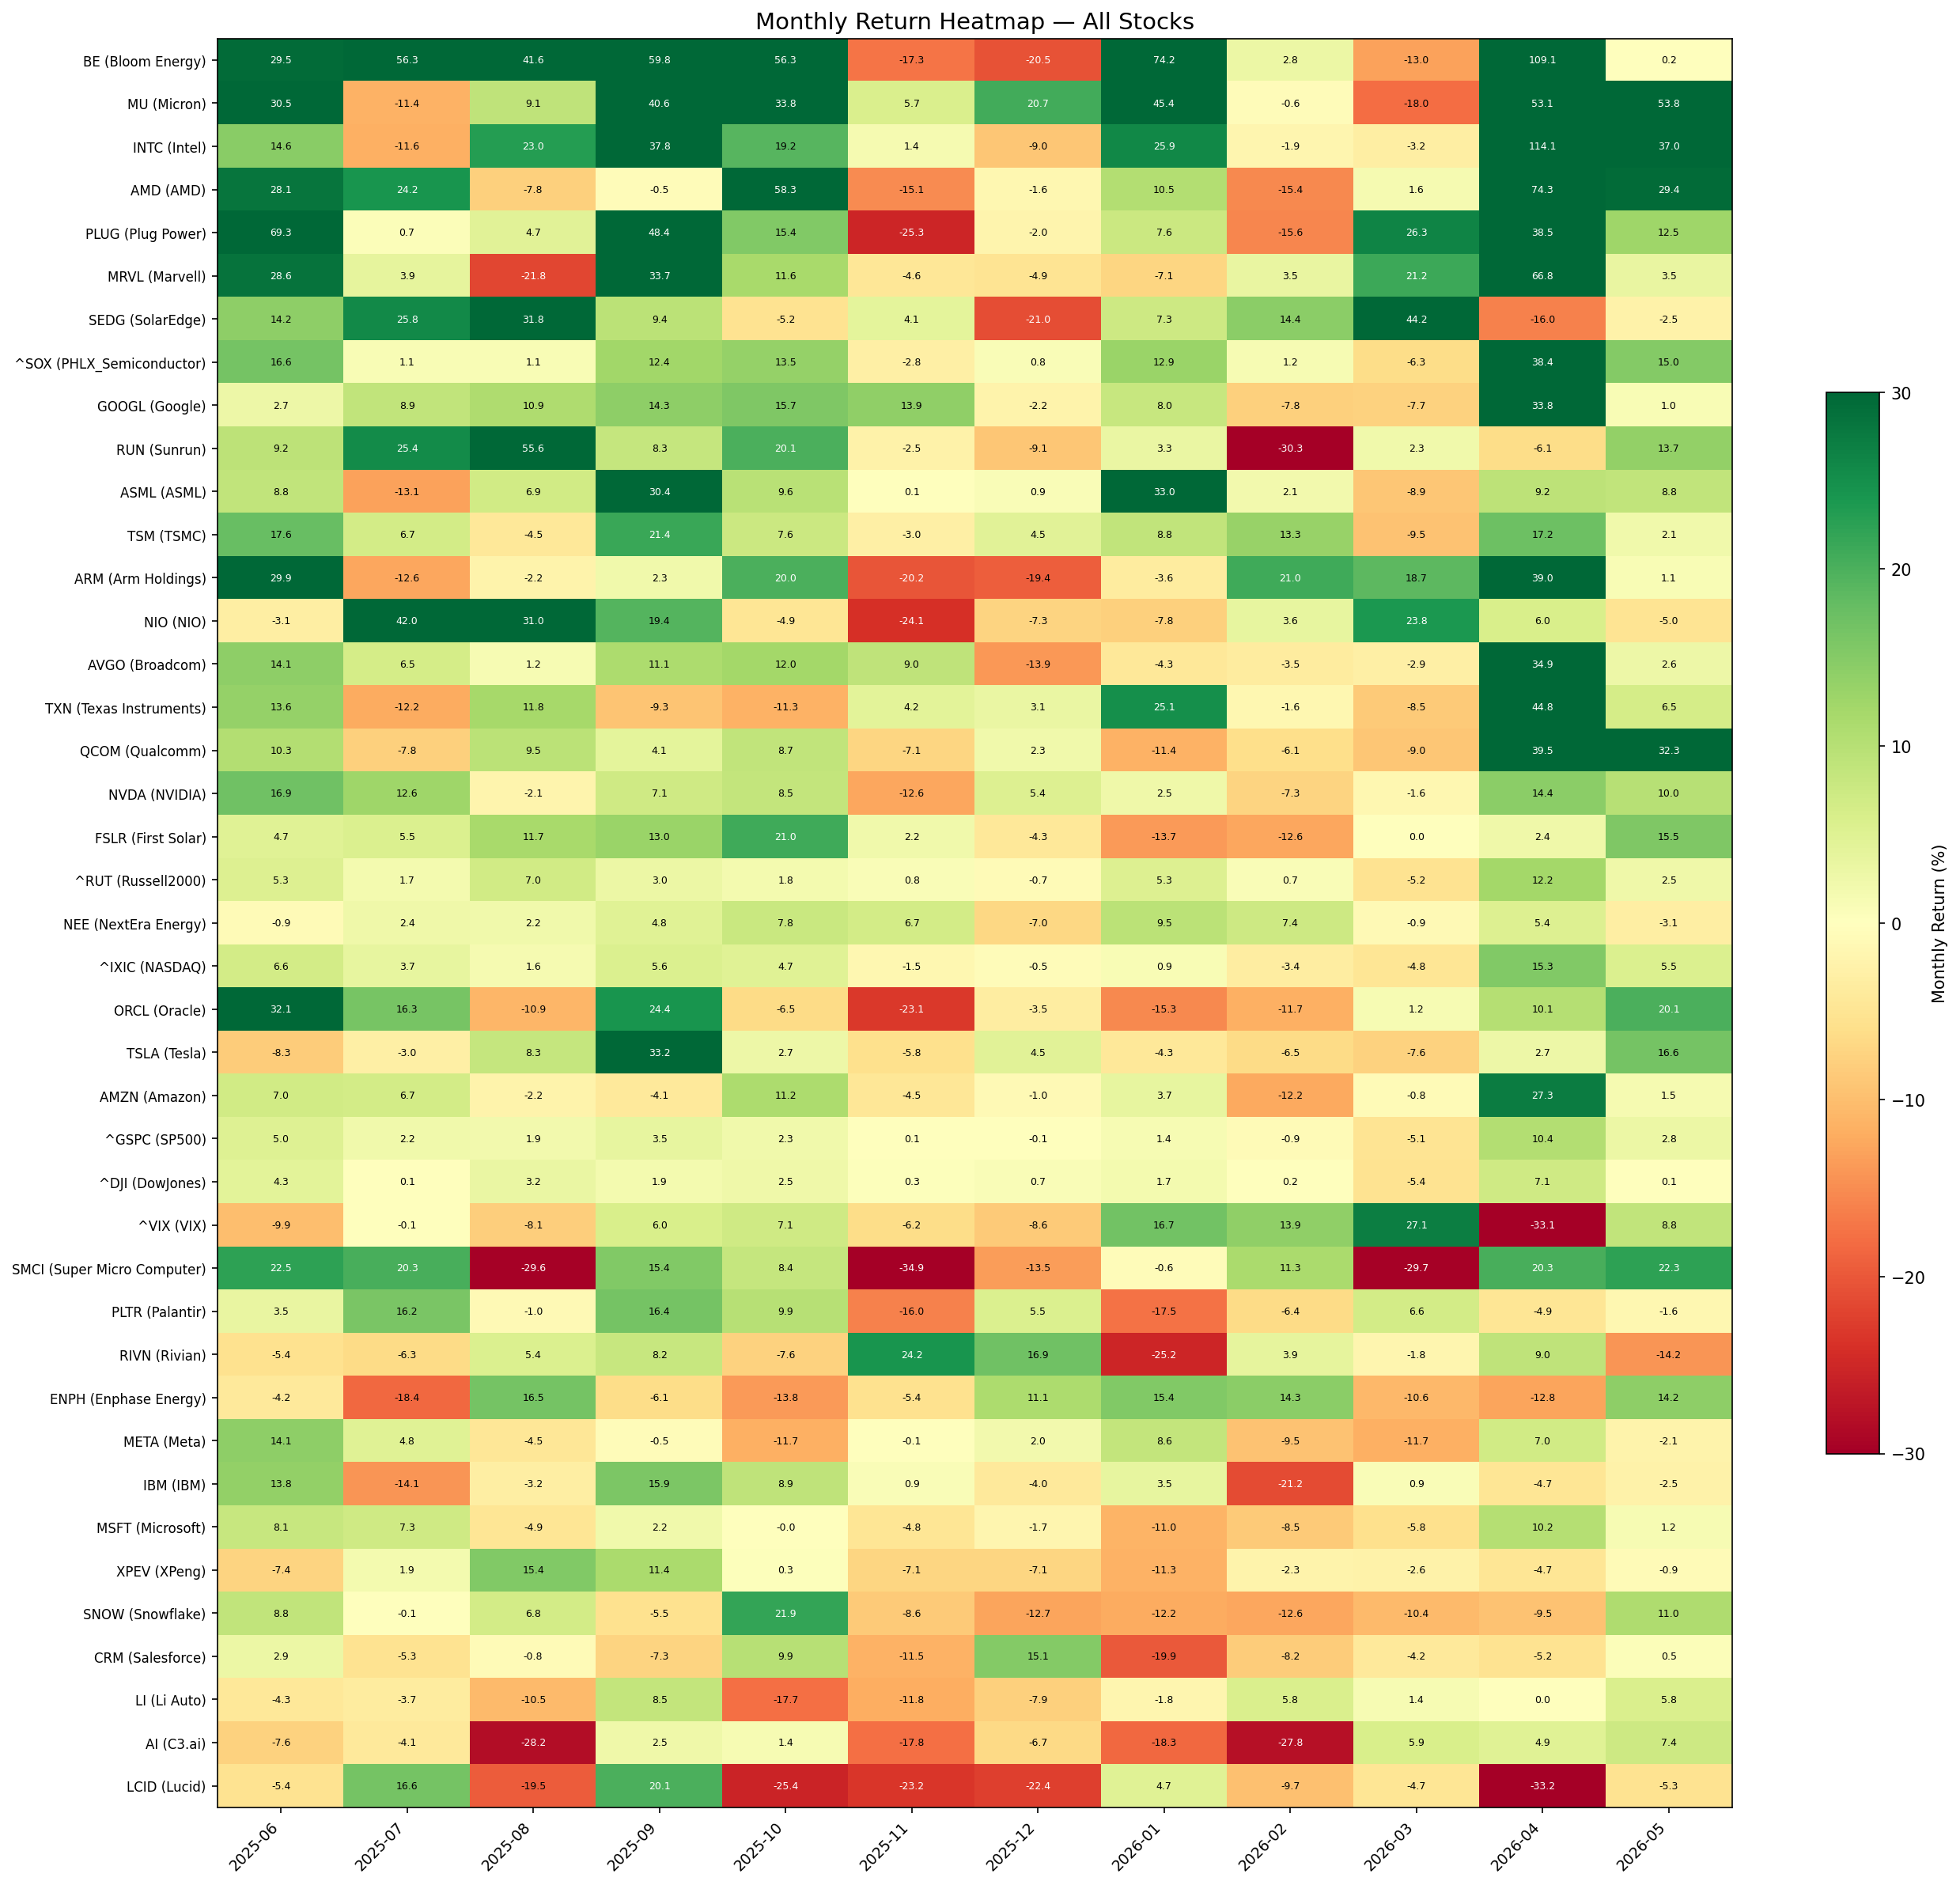

In [6]:
display(Image(str(CHART / "Part1_EDA/Step3_Returns/monthly_return_heatmap.png"), width=900))

---
## 第二部分：波动率分析

### 板块相关性决策

跨板块个股级平均相关性：AI vs 芯片 = 0.21，AI vs 新能源 = 0.12，芯片 vs 新能源 = 0.18。

**决策：** 新能源因相关性低于0.3阈值而从波动率分析中剔除。AI和芯片联动性明显更强。

### 第4步 — 年化波动率 & 第5步 — 滚动波动率

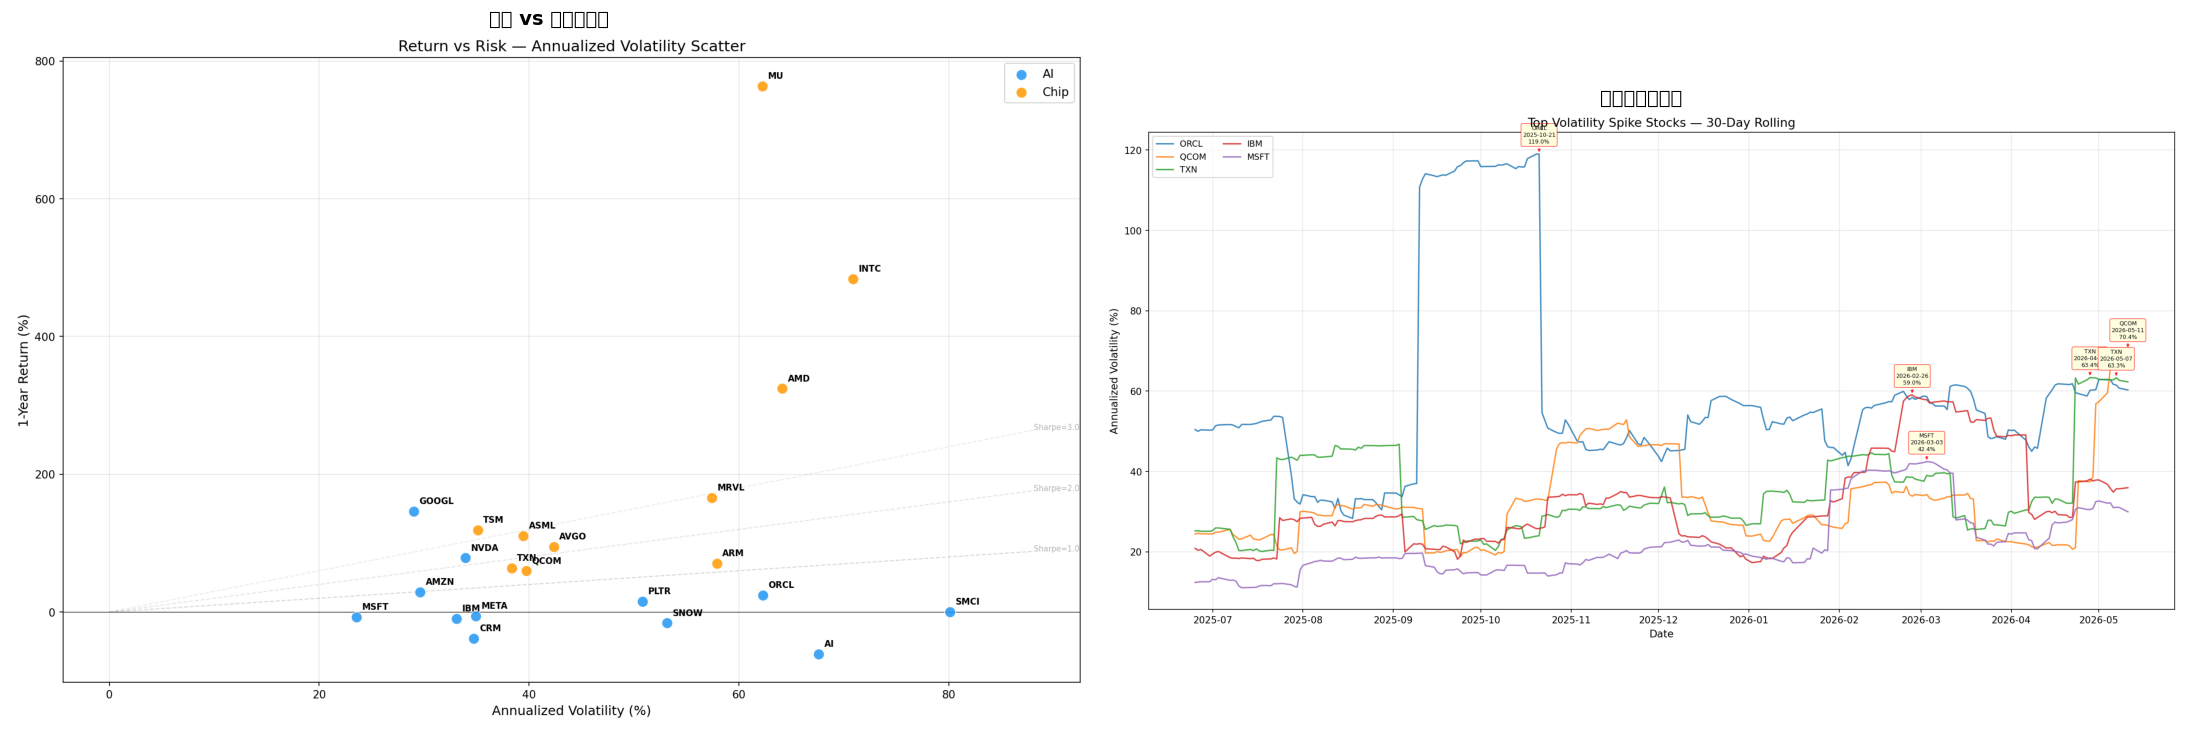

In [7]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(22, 8))
ax1.imshow(mpimg.imread(str(CHART / "Part2_Volatility/Step4_AnnualizedVol/return_vs_risk_scatter.png")))
ax1.set_title("收益 vs 风险散点图", fontsize=14, fontweight="bold")
ax1.axis("off")
ax2.imshow(mpimg.imread(str(CHART / "Part2_Volatility/Step5_RollingVol/volatility_spike_highlight.png")))
ax2.set_title("波动率异常检测", fontsize=14, fontweight="bold")
ax2.axis("off")
plt.tight_layout()
plt.show()

**主要波动率异常事件：**

| 标的 | 时间 | 峰值波动率 | 原因 |
|------|------|:--------:|------|
| ORCL | 2025年9-10月 | 119.0% | \$300B OpenAI云协议暴涨后财报不及预期暴跌 |
| QCOM | 2026年5月 | 70.4% | 财报超预期 + 中美关税暂停 + AI手机处理器消息 |
| IBM | 2026年2-3月 | 59.0% | 单日-13.15%，Anthropic COBOL颠覆叙事 |
| MSFT | 2026年2-3月 | 42.4% | 2008年以来最差季度，单日蒸发\$357B市值 |

---
## 第三部分：相关性分析

### 第6步 — AI与芯片相关性

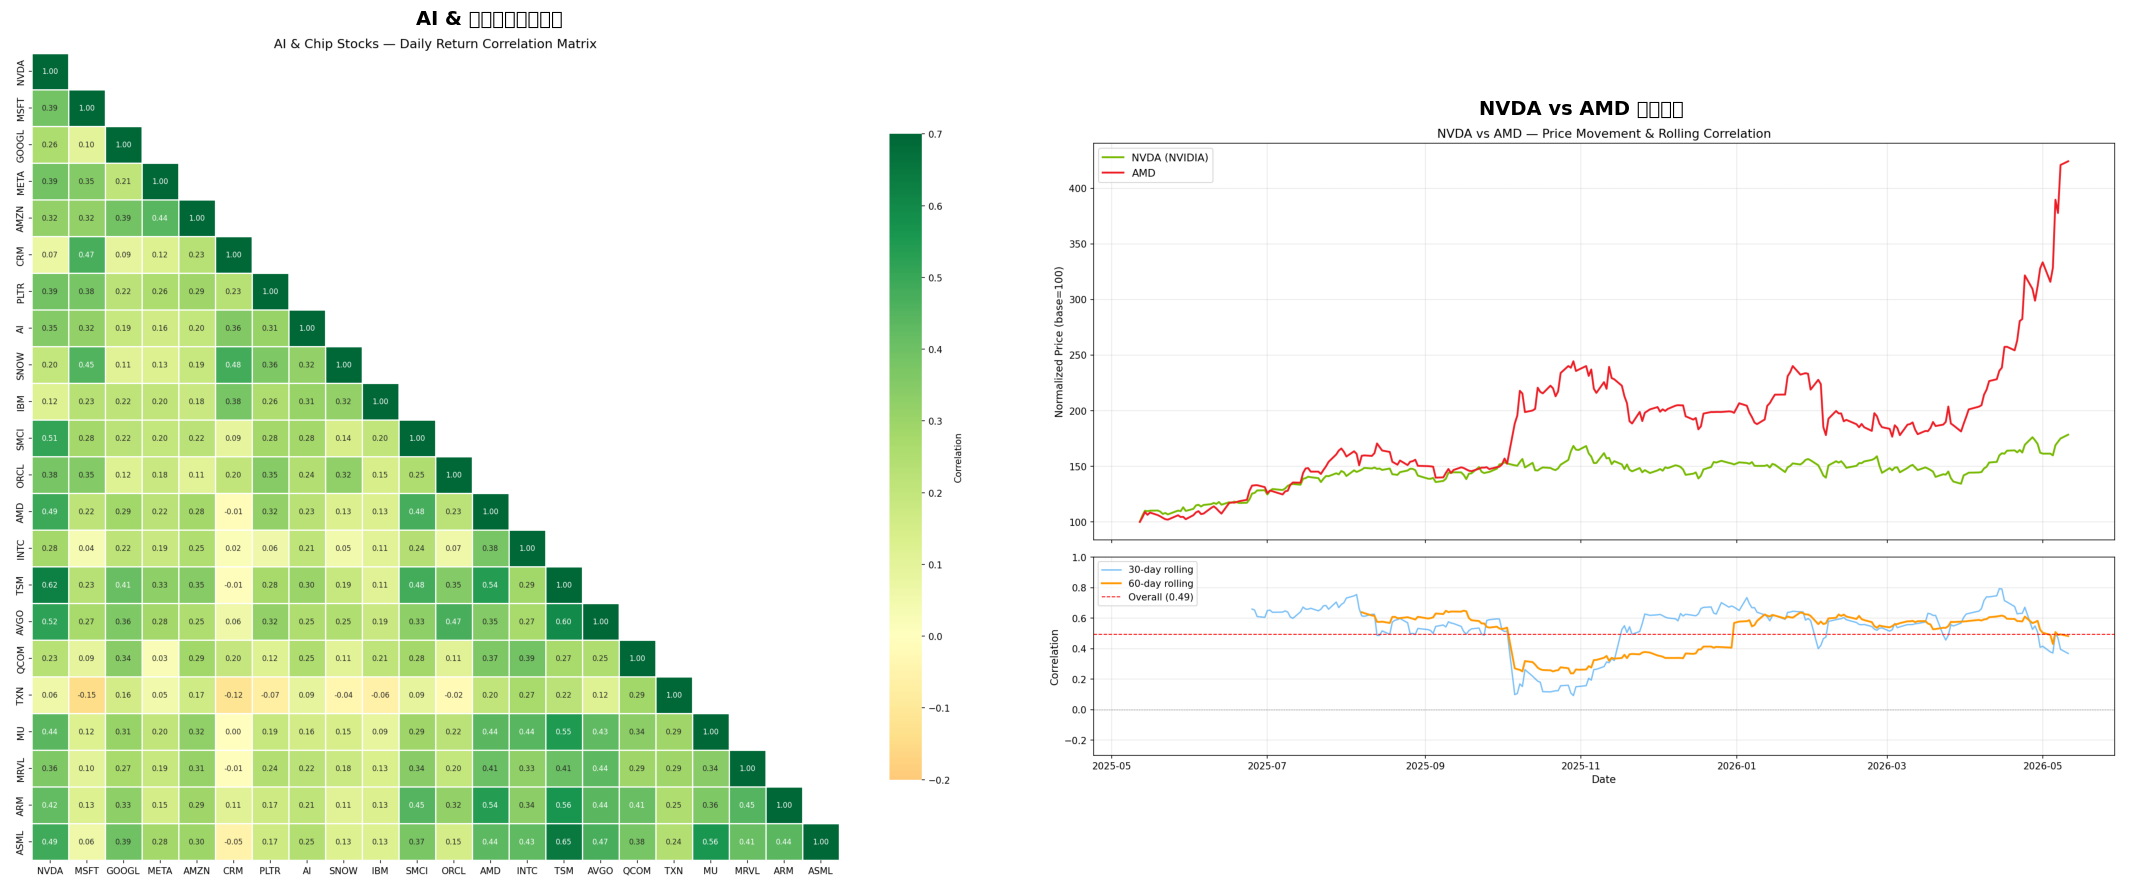

In [8]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(22, 9))
ax1.imshow(mpimg.imread(str(CHART / "Part3_Correlation/Step6_AIChipCorrelation/correlation_heatmap_ai_chip.png")))
ax1.set_title("AI & 芯片相关性热力图", fontsize=14, fontweight="bold")
ax1.axis("off")
ax2.imshow(mpimg.imread(str(CHART / "Part3_Correlation/Step6_AIChipCorrelation/nvda_vs_amd.png")))
ax2.set_title("NVDA vs AMD 深度分析", fontsize=14, fontweight="bold")
ax2.axis("off")
plt.tight_layout()
plt.show()

**关键发现：**
- **TSM是相关性枢纽**，与7只股票相关性 > 0.45（ASML 0.65, NVDA 0.62, AVGO 0.60）
- **NVDA vs AMD：** 相关性0.49，同方向天数68.4%——竞争对手但不可互换
- **TXN是异类：** 与多只AI股票负相关，独立于科技/AI生态系统

### 第7步 — Beta分析（对比标普500）

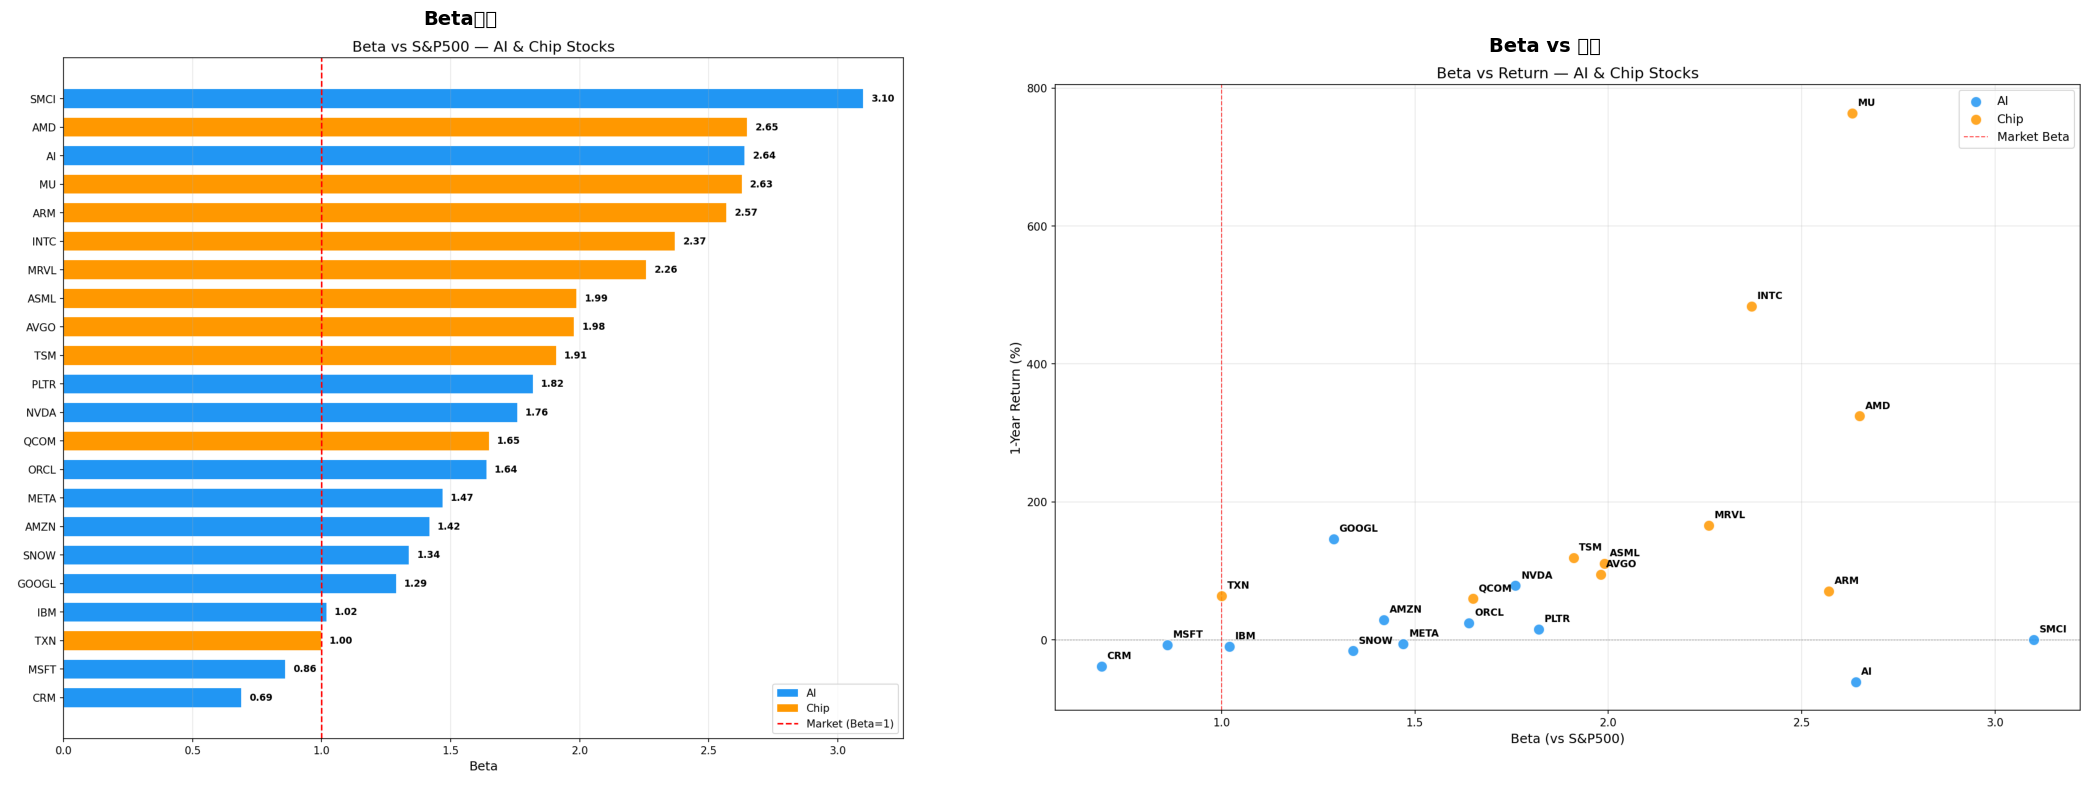

In [9]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(22, 8))
ax1.imshow(mpimg.imread(str(CHART / "Part3_Correlation/Step7_Beta/beta_ranking.png")))
ax1.set_title("Beta排名", fontsize=14, fontweight="bold")
ax1.axis("off")
ax2.imshow(mpimg.imread(str(CHART / "Part3_Correlation/Step7_Beta/beta_vs_return.png")))
ax2.set_title("Beta vs 收益", fontsize=14, fontweight="bold")
ax2.axis("off")
plt.tight_layout()
plt.show()

**高Beta ≠ 高收益：** SMCI（Beta 3.10）收益0%，GOOGL（Beta 1.29）收益+146%。应寻找正Alpha，而非仅追求高Beta。

---
## 第四部分：领涨领跌分析

### 第8步 — 滞后相关性 & 第9步 — 领导力评分

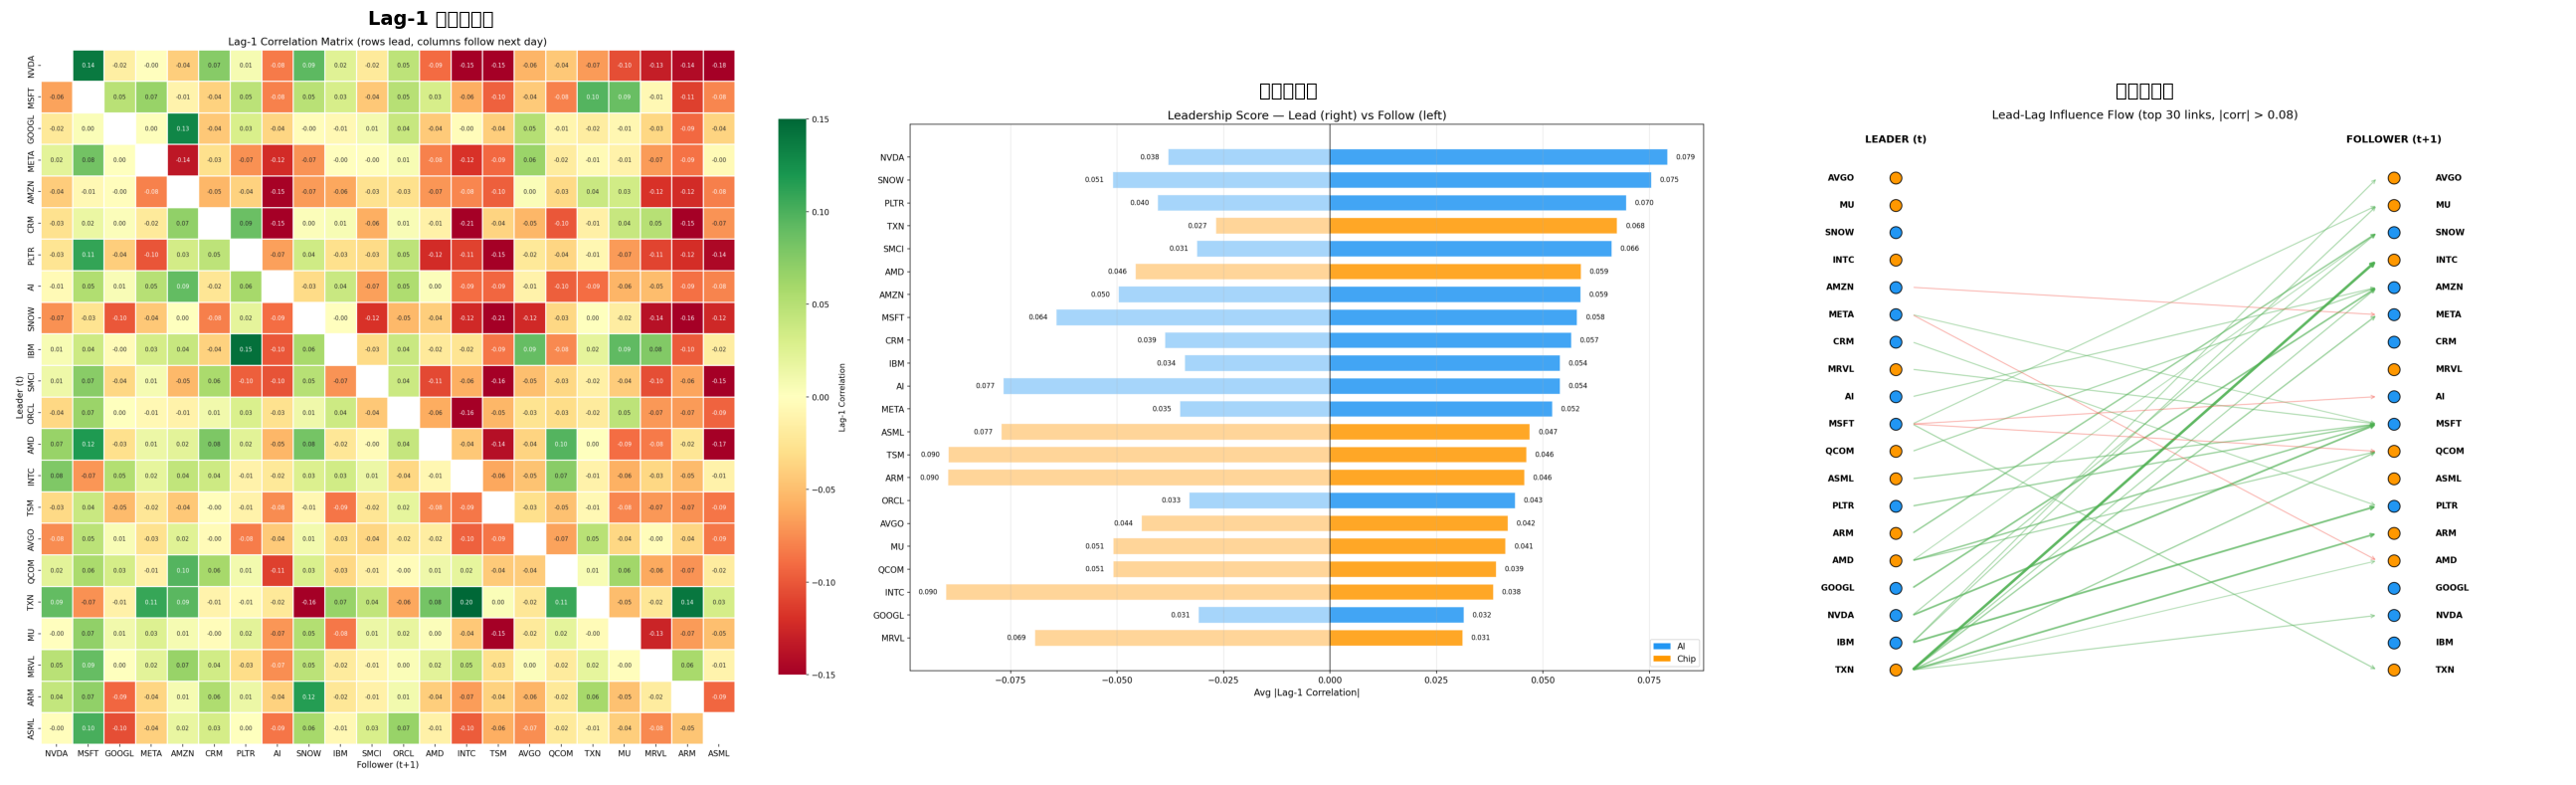

In [10]:
fig, axes = plt.subplots(1, 3, figsize=(26, 8))
imgs = [
    (CHART / "Part4_LeadLag/Step8_LaggedCorrelation/lag1_heatmap.png", "Lag-1 相关性矩阵"),
    (CHART / "Part4_LeadLag/Step9_Leadership/leadership_score.png", "领导力评分"),
    (CHART / "Part4_LeadLag/Step9_Leadership/influence_flow.png", "影响力流向"),
]
for ax, (path, title) in zip(axes, imgs):
    ax.imshow(mpimg.imread(str(path)))
    ax.set_title(title, fontsize=14, fontweight="bold")
    ax.axis("off")
plt.tight_layout()
plt.show()

In [11]:
scores = pd.read_csv(CHART / "Part4_LeadLag/Step9_Leadership/leadership_scores.csv")
leaders = scores[scores["Lead_Ratio"] > 1.2].sort_values("Lead_Ratio", ascending=False)
followers = scores[scores["Lead_Ratio"] < 0.8].sort_values("Lead_Ratio")

print("纯领涨股（Lead_Ratio > 1.2）")
display(leaders[["Ticker", "Name", "Sector", "Avg_Lead_Corr", "Lead_Ratio", "Strongest_Leads", "Lead_Corr"]])
print("\n纯跟涨股（Lead_Ratio < 0.8）")
display(followers[["Ticker", "Name", "Sector", "Avg_Follow_Corr", "Lead_Ratio", "Strongest_Follows", "Follow_Corr"]])

纯领涨股（Lead_Ratio > 1.2）


,Ticker,Name,Sector,Avg_Lead_Corr,Lead_Ratio,Strongest_Leads,Lead_Corr
17,TXN,Texas Instruments,Chip,0.0675,2.52,INTC,0.2028
10,SMCI,Super Micro Computer,AI,0.0662,2.12,TSM,-0.1610
0,NVDA,NVIDIA,AI,0.0793,2.09,ASML,-0.1788
6,PLTR,Palantir,AI,0.0696,1.73,TSM,-0.1546
9,IBM,IBM,AI,0.0541,1.59,PLTR,0.1451
3,META,Meta,AI,0.0523,1.49,AMZN,-0.1350
8,SNOW,Snowflake,AI,0.0755,1.48,TSM,-0.2053
5,CRM,Salesforce,AI,0.0567,1.47,INTC,-0.2068
11,ORCL,Oracle,AI,0.0435,1.32,INTC,-0.1626
12,AMD,AMD,Chip,0.0590,1.29,ASML,-0.1653



纯跟涨股（Lead_Ratio < 0.8）


,Ticker,Name,Sector,Avg_Follow_Corr,Lead_Ratio,Strongest_Follows,Follow_Corr
13,INTC,Intel,Chip,0.0901,0.43,CRM,-0.2068
19,MRVL,Marvell,Chip,0.0693,0.45,SNOW,-0.1388
20,ARM,Arm Holdings,Chip,0.0897,0.51,SNOW,-0.1647
14,TSM,TSMC,Chip,0.0896,0.52,SNOW,-0.2053
21,ASML,ASML,Chip,0.0771,0.61,NVDA,-0.1788
7,AI,C3.ai,AI,0.0767,0.71,CRM,-0.1542
16,QCOM,Qualcomm,Chip,0.0509,0.77,TXN,0.1067


**信息流动层级：**

```
信号源头：TXN(2.52)、NVDA(2.09)、SMCI(2.12)、PLTR(1.73)  ← 领涨股
    │
    │ 1-2天滞后
    ▼
信号接收：INTC(0.43)、MRVL(0.45)、ARM(0.51)、TSM(0.52)  ← 跟涨股
```

影响力从AI/平台公司向下游传导至芯片供应链，与现实中的半导体供应链层级完全吻合。

---
## 第五部分：风险分析

### 第10步 — 回撤分析

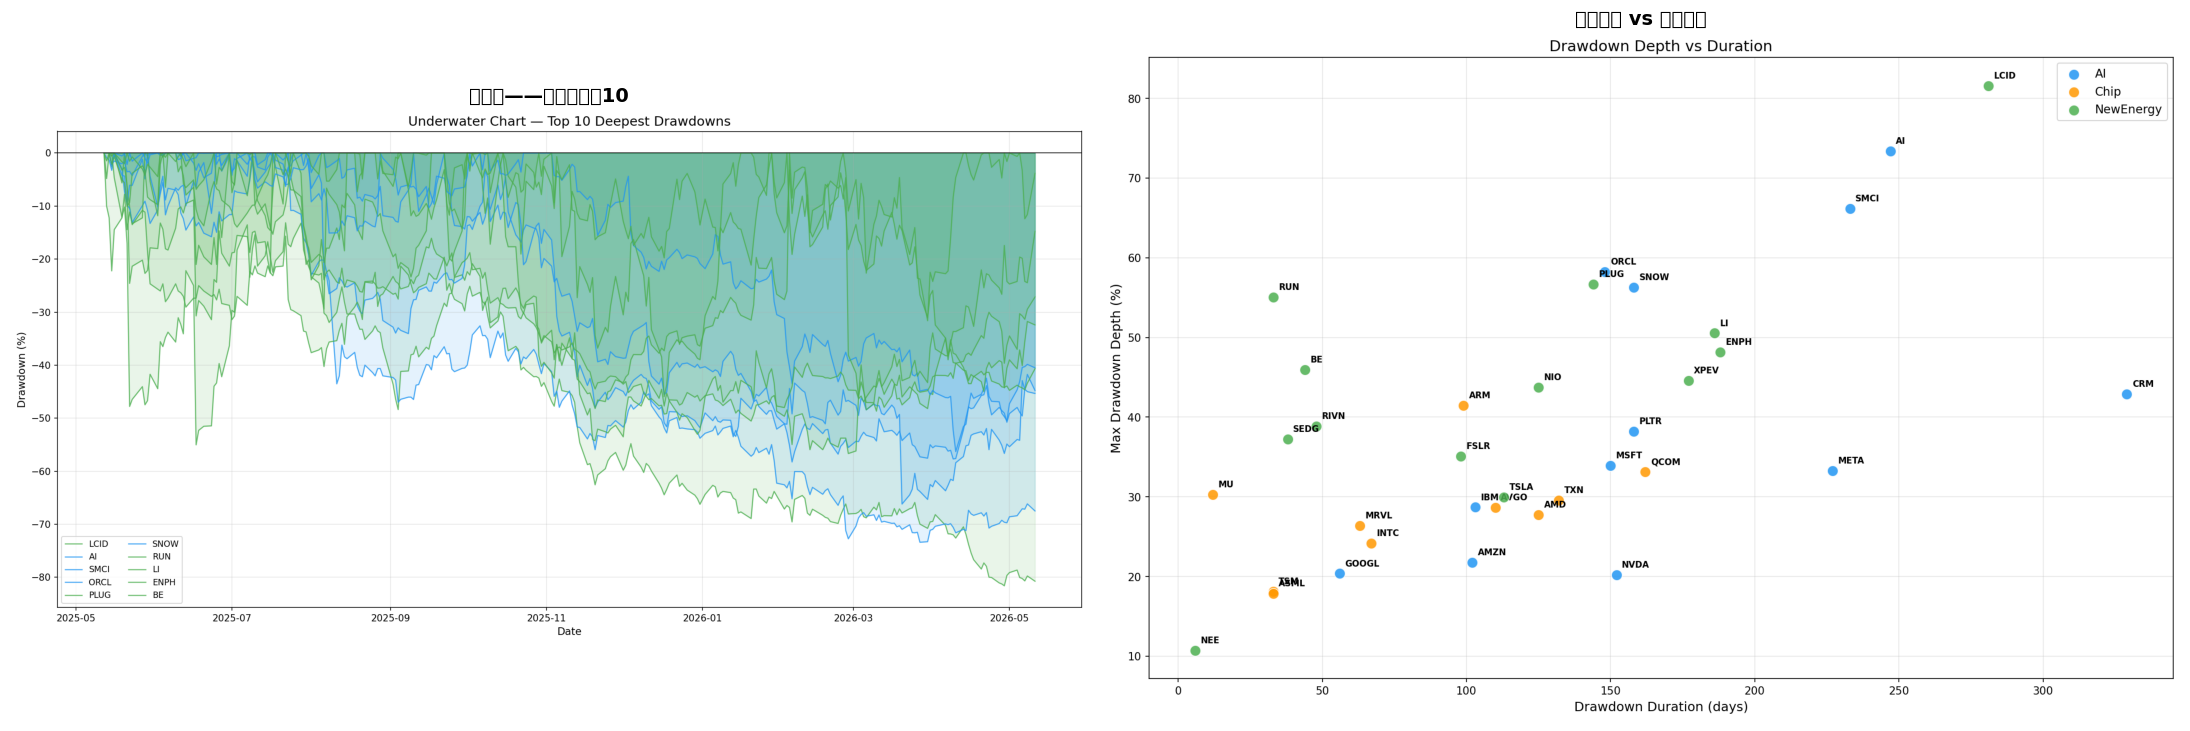

In [12]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(22, 8))
ax1.imshow(mpimg.imread(str(CHART / "Part5_Risk/Step10_Drawdown/underwater_top10.png")))
ax1.set_title("水下图——最大回撤前10", fontsize=14, fontweight="bold")
ax1.axis("off")
ax2.imshow(mpimg.imread(str(CHART / "Part5_Risk/Step10_Drawdown/drawdown_depth_vs_duration.png")))
ax2.set_title("回撤深度 vs 持续时间", fontsize=14, fontweight="bold")
ax2.axis("off")
plt.tight_layout()
plt.show()

In [13]:
dd = pd.read_csv(CHART / "Part5_Risk/Step10_Drawdown/drawdown_analysis.csv")
print("最大回撤前10（按严重程度排序）")
display(dd.nsmallest(10, "Max_Drawdown%")[
    ["Ticker", "Name", "Sector", "Max_Drawdown%", "Peak_Date", "Trough_Date", "Drawdown_Days", "Recovery_Date"]
].reset_index(drop=True))

最大回撤前10（按严重程度排序）


,Ticker,Name,Sector,Max_Drawdown%,Peak_Date,Trough_Date,Drawdown_Days,Recovery_Date
0,LCID,Lucid,NewEnergy,-81.60,2025-07-22,2026-04-29,281,Not recovered
1,AI,C3.ai,AI,-73.39,2025-07-23,2026-03-27,247,Not recovered
2,SMCI,Super Micro Computer,AI,-66.18,2025-07-30,2026-03-20,233,Not recovered
3,ORCL,Oracle,AI,-58.25,2025-09-10,2026-02-05,148,Not recovered
4,PLUG,Plug Power,NewEnergy,-56.66,2025-10-06,2026-02-27,144,Not recovered
5,SNOW,Snowflake,AI,-56.30,2025-11-03,2026-04-10,158,Not recovered
6,RUN,Sunrun,NewEnergy,-55.02,2025-05-15,2025-06-17,33,2025-08-15
7,LI,Li Auto,NewEnergy,-50.53,2025-07-18,2026-01-20,186,Not recovered
8,ENPH,Enphase Energy,NewEnergy,-48.17,2025-05-16,2025-11-20,188,2026-02-04
9,BE,Bloom Energy,NewEnergy,-45.94,2025-11-03,2025-12-17,44,2026-01-16


### 第11步 — 风险指标（VaR、夏普、索提诺、卡尔马）

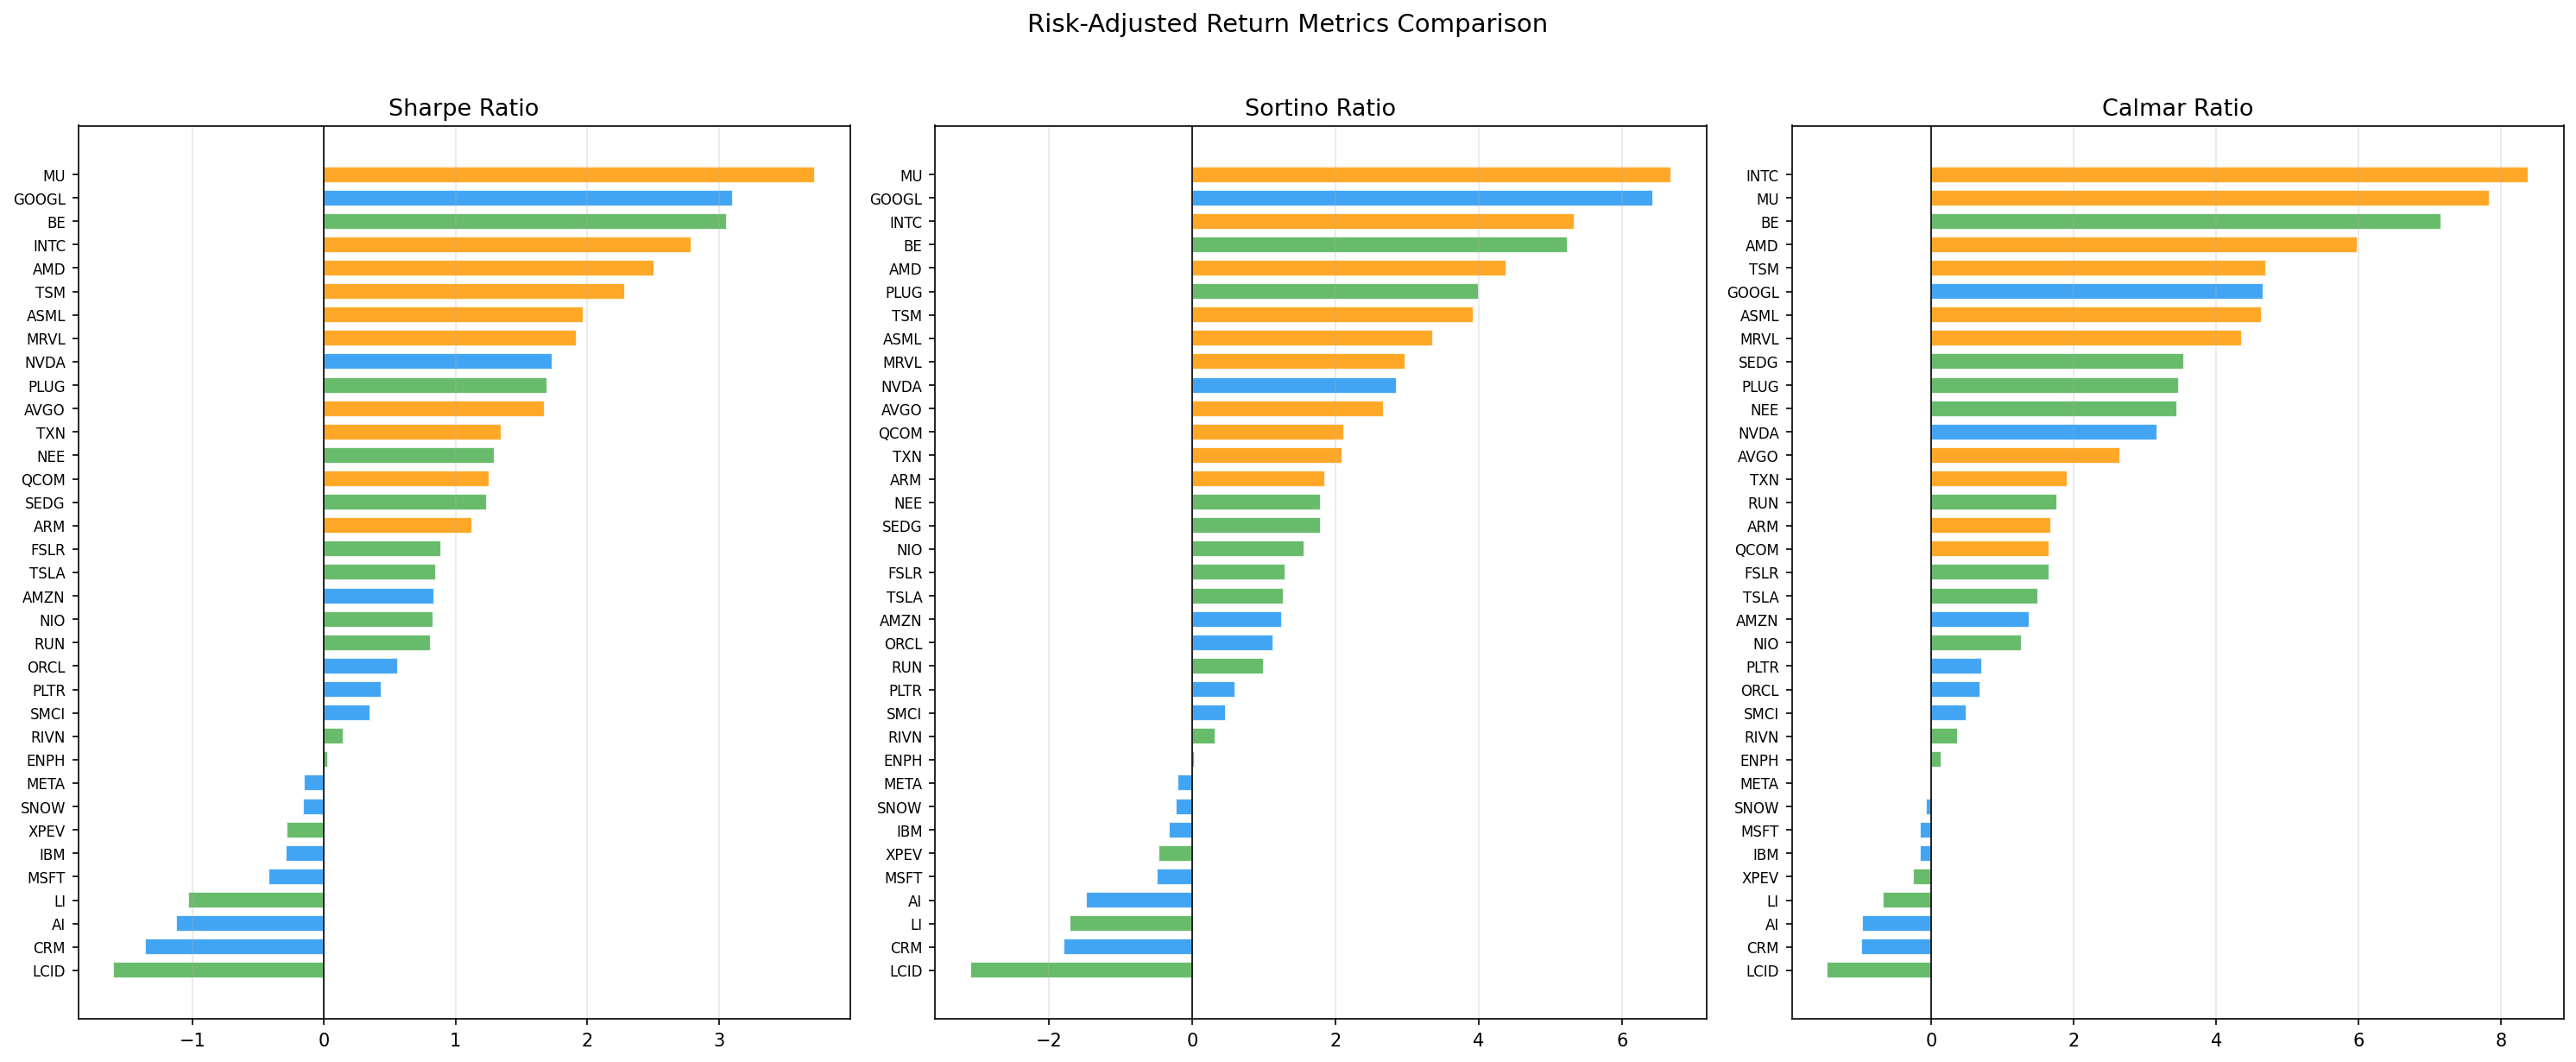

In [14]:
display(Image(str(CHART / "Part5_Risk/Step11_RiskMetrics/risk_ratios_comparison.png"), width=950))

In [15]:
risk = pd.read_csv(CHART / "Part5_Risk/Step11_RiskMetrics/risk_metrics.csv")

print("板块风险摘要")
sector_risk = risk.groupby("Sector").agg({
    "Ann_Return%": "mean", "Ann_Vol%": "mean", "Sharpe": "mean",
    "Sortino": "mean", "Max_DD%": "mean", "VaR_95_Hist%": "mean", "Beta": "mean",
}).round(2)
sector_risk.index = sector_risk.index.map({"AI": "AI科技", "Chip": "芯片", "NewEnergy": "新能源"})
display(sector_risk.sort_values("Sharpe", ascending=False))

print("\n夏普比率前10")
display(risk.nlargest(10, "Sharpe")[
    ["Ticker", "Name", "Sector", "Ann_Return%", "Ann_Vol%", "Sharpe", "Sortino", "Calmar", "Beta"]
].reset_index(drop=True))

板块风险摘要


,Ann_Return%,Ann_Vol%,Sharpe,Sortino,Max_DD%,VaR_95_Hist%,Beta
Sector,,,,,,,
芯片,114.70,50.75,2.06,3.54,-27.74,-3.93,2.10
新能源,62.24,72.56,0.61,1.00,-44.47,-6.06,1.83
AI科技,13.60,44.40,0.30,0.68,-41.12,-4.02,1.59



夏普比率前10


,Ticker,Name,Sector,Ann_Return%,Ann_Vol%,Sharpe,Sortino,Calmar,Beta
0,MU,Micron,Chip,237.31,62.22,3.73,6.69,7.84,2.63
1,GOOGL,Google,AI,95.06,29.00,3.11,6.43,4.67,1.29
2,BE,Bloom Energy,NewEnergy,328.87,105.89,3.06,5.24,7.16,3.74
3,INTC,Intel,Chip,202.59,70.88,2.79,5.34,8.38,2.37
4,AMD,AMD,Chip,166.01,64.11,2.51,4.38,5.98,2.65
5,TSM,TSMC,Chip,85.26,35.10,2.29,3.93,4.70,1.91
6,ASML,ASML,Chip,82.78,39.45,1.97,3.36,4.64,1.99
7,MRVL,Marvell,Chip,115.00,57.40,1.92,2.98,4.36,2.26
8,NVDA,NVIDIA,AI,64.15,33.92,1.74,2.85,3.17,1.76
9,PLUG,Plug Power,NewEnergy,197.19,112.81,1.70,4.00,3.48,2.67


**芯片板块在每一项风险调整指标中领先。** 新能源日VaR最差（-6.1%），尾部风险最高的标的全部来自新能源（RUN -25.8%，ENPH -14.7%）。

---
## 第六部分：组合优化

### 第12步 — 有效前沿

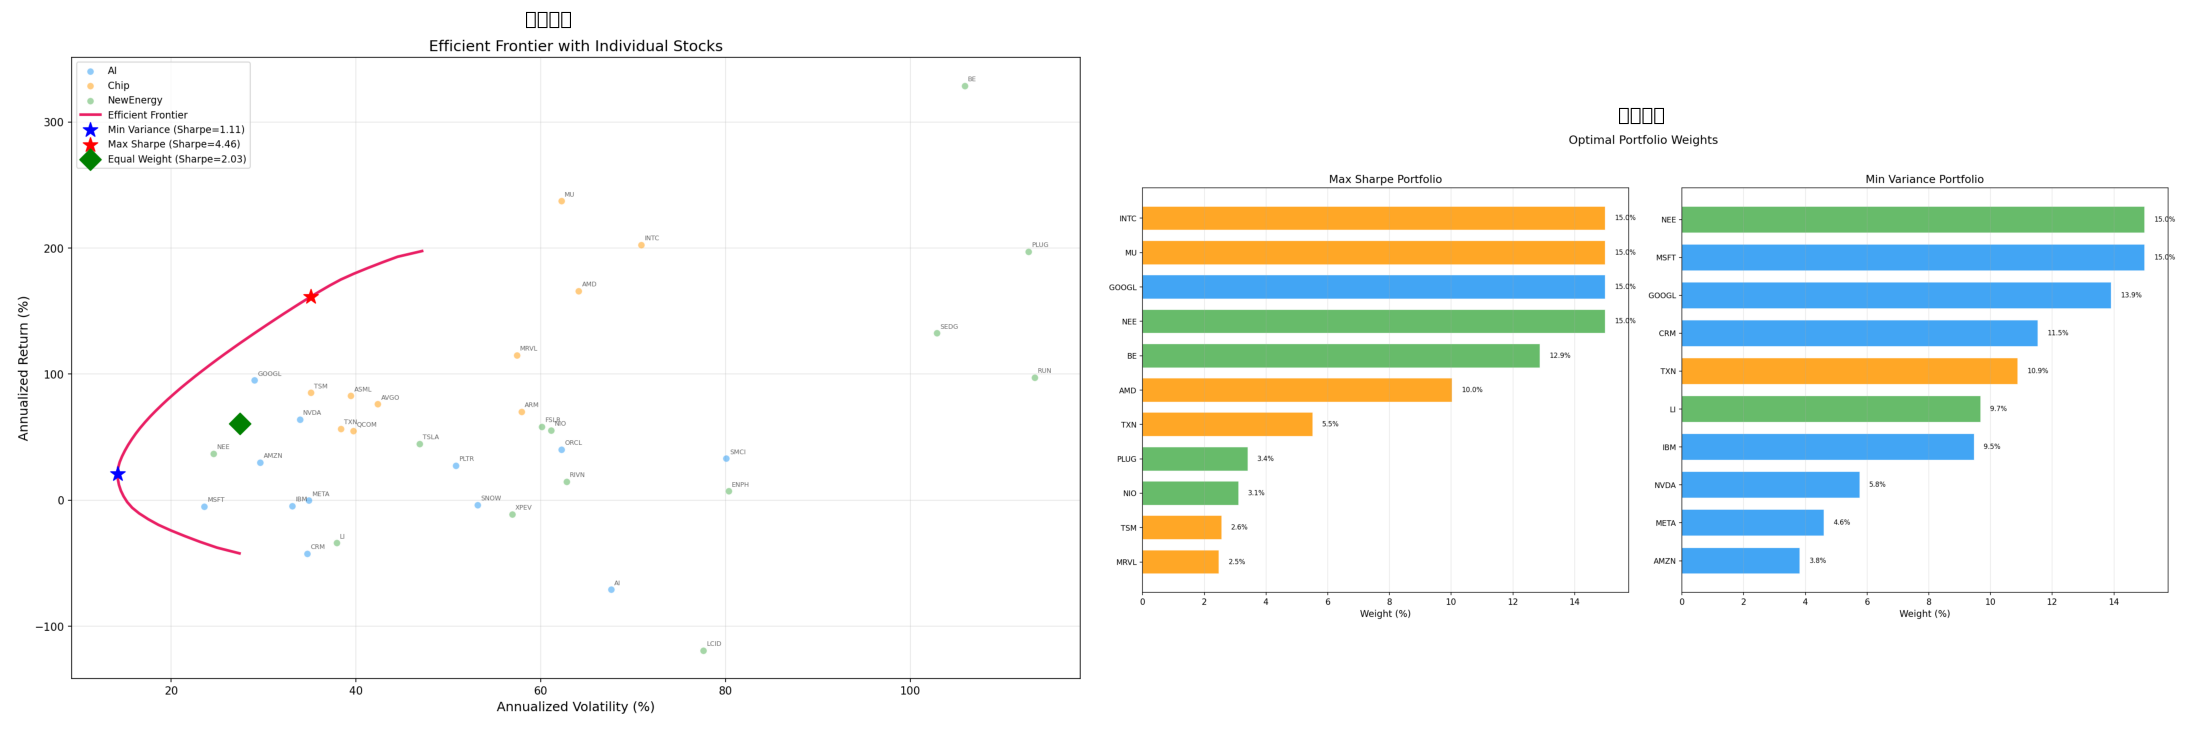

In [16]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(22, 8))
ax1.imshow(mpimg.imread(str(CHART / "Part6_Portfolio/Step12_EfficientFrontier/efficient_frontier.png")))
ax1.set_title("有效前沿", fontsize=14, fontweight="bold")
ax1.axis("off")
ax2.imshow(mpimg.imread(str(CHART / "Part6_Portfolio/Step12_EfficientFrontier/optimal_weights.png")))
ax2.set_title("最优权重", fontsize=14, fontweight="bold")
ax2.axis("off")
plt.tight_layout()
plt.show()

In [17]:
weights = pd.read_csv(CHART / "Part6_Portfolio/Step12_EfficientFrontier/optimal_weights.csv")

print("最大夏普组合——核心持仓（权重 > 1%）")
ms = weights[weights["MaxSharpe_Weight%"] > 1].sort_values("MaxSharpe_Weight%", ascending=False)
display(ms[["Ticker", "Name", "Sector", "MaxSharpe_Weight%"]].reset_index(drop=True))

print("\n最小方差组合——核心持仓（权重 > 1%）")
mv = weights[weights["MinVar_Weight%"] > 1].sort_values("MinVar_Weight%", ascending=False)
display(mv[["Ticker", "Name", "Sector", "MinVar_Weight%"]].reset_index(drop=True))

print("\n板块配置对比")
alloc = []
for label, col in [("最大夏普", "MaxSharpe_Weight%"), ("最小方差", "MinVar_Weight%"), ("等权", "EqualWeight%")]:
    row = {"组合": label}
    for sector in ["AI", "Chip", "NewEnergy"]:
        pct = weights[weights["Sector"] == sector][col].sum()
        row[{"AI": "AI科技", "Chip": "芯片", "NewEnergy": "新能源"}[sector]] = f"{pct:.1f}%"
    alloc.append(row)
display(pd.DataFrame(alloc).set_index("组合"))

最大夏普组合——核心持仓（权重 > 1%）


,Ticker,Name,Sector,MaxSharpe_Weight%
0,GOOGL,Google,AI,15.00
1,INTC,Intel,Chip,15.00
2,MU,Micron,Chip,15.00
3,NEE,NextEra Energy,NewEnergy,15.00
4,BE,Bloom Energy,NewEnergy,12.88
5,AMD,AMD,Chip,10.03
6,TXN,Texas Instruments,Chip,5.51
7,PLUG,Plug Power,NewEnergy,3.41
8,NIO,NIO,NewEnergy,3.12
9,TSM,TSMC,Chip,2.56



最小方差组合——核心持仓（权重 > 1%）


,Ticker,Name,Sector,MinVar_Weight%
0,MSFT,Microsoft,AI,15.00
1,NEE,NextEra Energy,NewEnergy,15.00
2,GOOGL,Google,AI,13.91
3,CRM,Salesforce,AI,11.54
4,TXN,Texas Instruments,Chip,10.88
5,LI,Li Auto,NewEnergy,9.69
6,IBM,IBM,AI,9.48
7,NVDA,NVIDIA,AI,5.77
8,META,Meta,AI,4.60
9,AMZN,Amazon,AI,3.83



板块配置对比


,AI科技,芯片,新能源
组合,,,
最大夏普,15.0%,50.6%,34.4%
最小方差,64.1%,11.2%,24.7%
等权,34.3%,28.6%,37.2%


### 第13步 — 组合回测

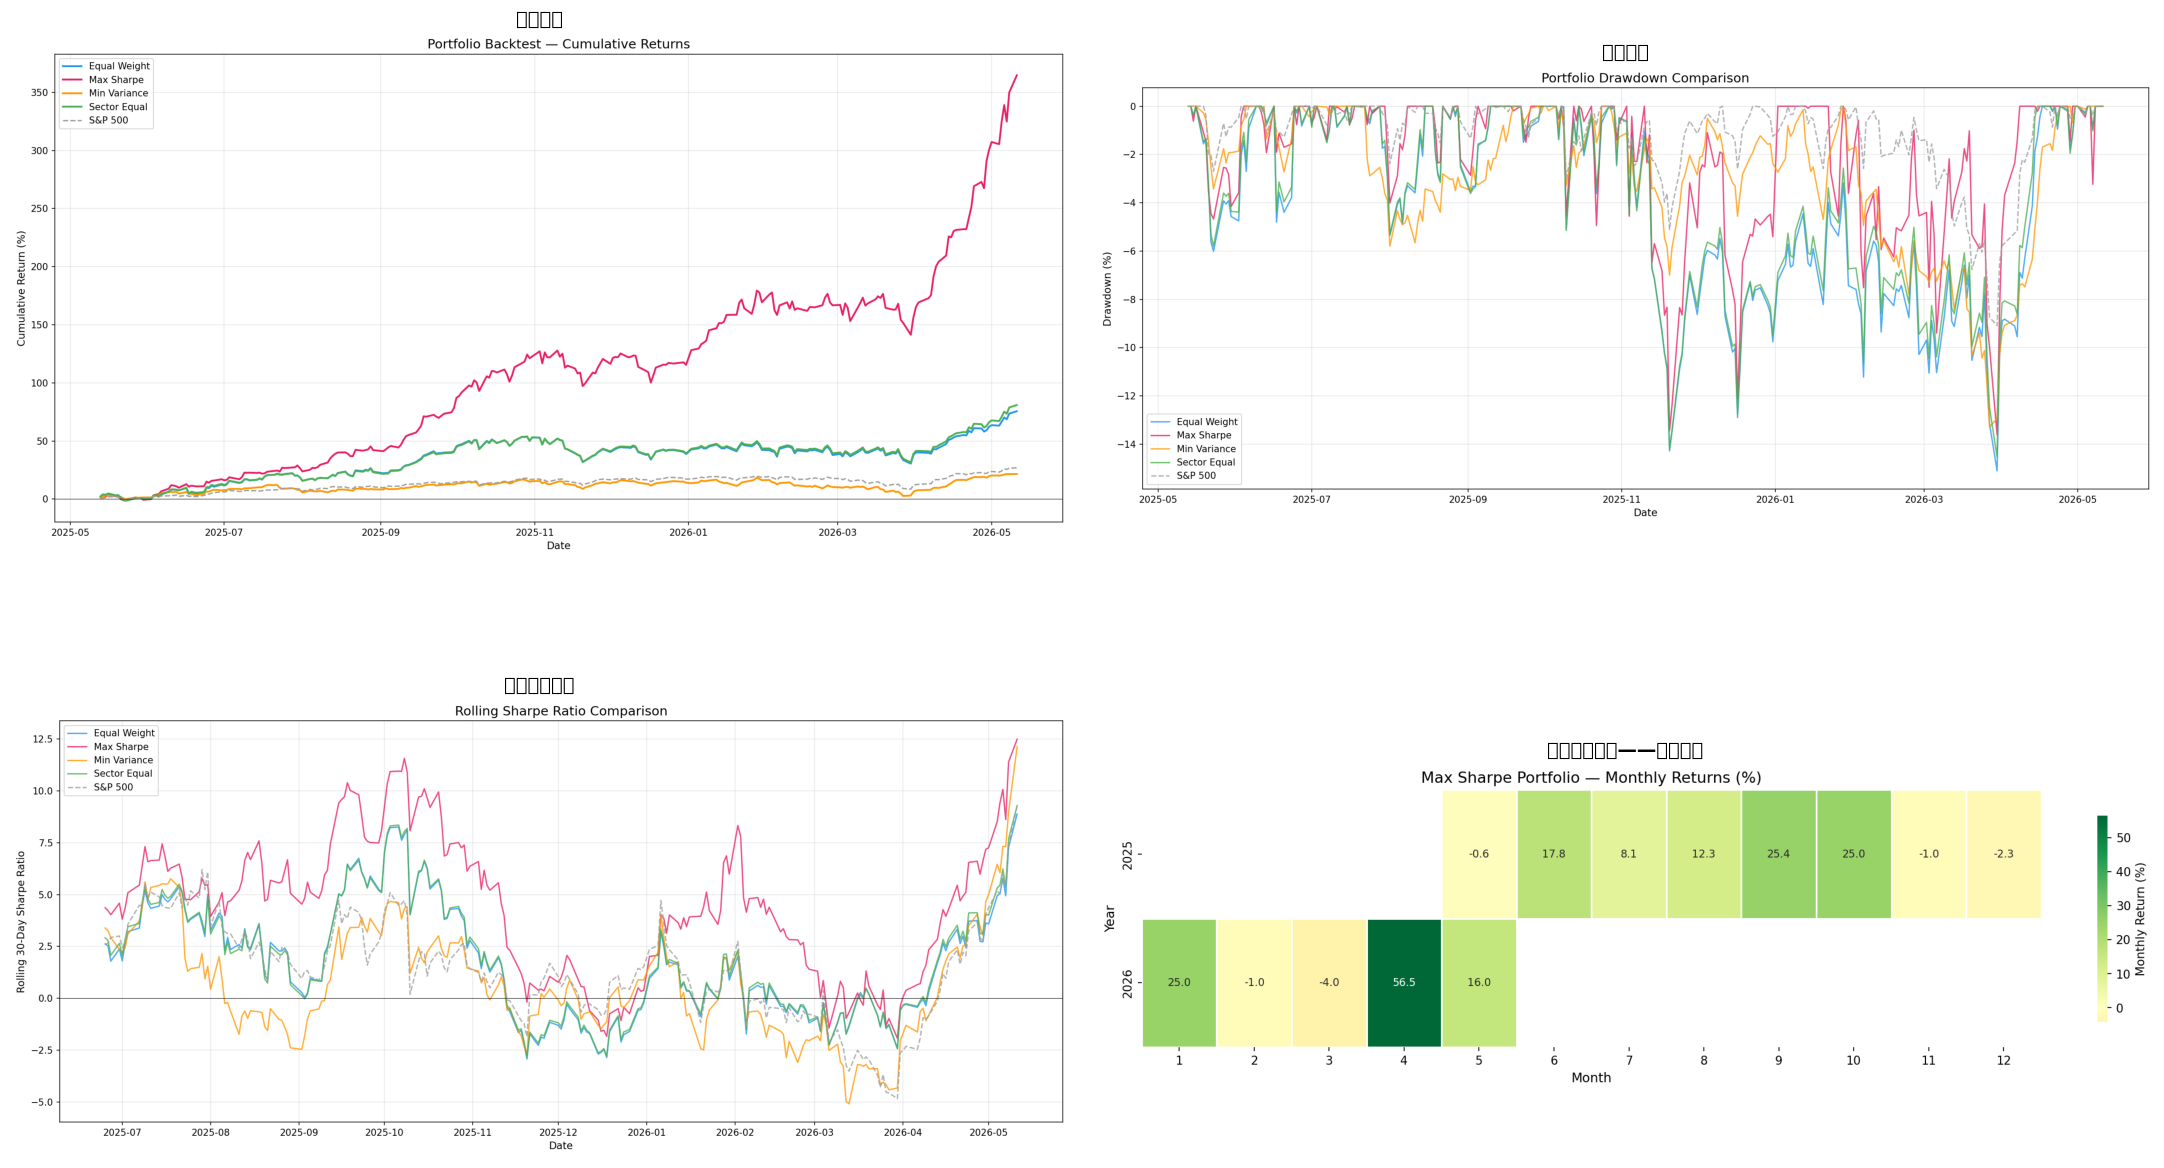

In [18]:
fig, axes = plt.subplots(2, 2, figsize=(22, 14))
imgs = [
    (CHART / "Part6_Portfolio/Step13_Backtest/cumulative_returns.png", "累计收益"),
    (CHART / "Part6_Portfolio/Step13_Backtest/drawdown_comparison.png", "回撤对比"),
    (CHART / "Part6_Portfolio/Step13_Backtest/rolling_sharpe.png", "滚动夏普比率"),
    (CHART / "Part6_Portfolio/Step13_Backtest/monthly_returns_heatmap.png", "最大夏普组合——月度收益"),
]
for ax, (path, title) in zip(axes.flat, imgs):
    ax.imshow(mpimg.imread(str(path)))
    ax.set_title(title, fontsize=14, fontweight="bold")
    ax.axis("off")
plt.tight_layout(pad=2)
plt.show()

In [19]:
print("组合表现对比")
portfolio_perf = pd.read_csv(CHART / "Part6_Portfolio/Step13_Backtest/portfolio_performance.csv")
display(portfolio_perf.set_index("Portfolio"))

组合表现对比


,Total_Return%,Ann_Return%,Ann_Vol%,Sharpe,Sortino,Max_DD%,Calmar,Win_Rate%
Portfolio,,,,,,,,
Equal Weight,75.59,60.55,27.42,2.03,3.14,-15.11,4.01,56.4
Max Sharpe,364.75,161.45,35.10,4.46,6.82,-13.61,11.86,63.6
Min Variance,21.56,20.69,14.18,1.11,1.69,-13.29,1.56,58.0
Sector Equal,80.90,63.51,27.24,2.15,3.34,-14.54,4.37,56.0
S&P 500,26.84,24.71,12.09,1.63,2.34,-9.10,2.72,57.2


> **注意：** 这是静态权重、无再平衡的样本内回测。实际表现会因交易成本、滑点和无法提前获知最优权重而低于回测结果。

---
## 总结

### 五大关键发现

**1. 硅片胜过软件。**
芯片板块（+225.5%）大幅跑赢AI软件（+13.0%）。市场奖励物理层面构建AI基础设施的公司，而非试图销售AI功能的公司。

**2. 信息流动遵循供应链层级。**
需求信号从AI算力买方（NVDA、PLTR、SMCI）以1–2天延迟传导至半导体制造商（TSM、INTC、ASML）。

**3. 新能源是分散化工具，而非协同板块。**
跨板块个股相关性低于0.18。板块内部表现极度分化（BE +1401% vs LCID -77%）。

**4. 高Beta不等于高收益。**
SMCI（Beta 3.10）收益0%，GOOGL（Beta 1.29）收益+146%。最佳风险调整收益来自中等Beta + 强基本面。

**5. 组合优化有效。**
均值-方差最大夏普组合以4.7倍优势跑赢等权组合（+364.8% vs +75.6%），证明系统性权重分配在简单纯多头框架下也能显著改善收益。

### 投资组合启示

| 类别 | 标的 | 理由 |
|------|------|------|
| **核心持仓** | GOOGL、TSM、ASML | 最佳风险调整收益（夏普2.1–3.3），中等波动率 |
| **成长配置** | MU、AMD、INTC | 最高收益，搭乘芯片超级周期 |
| **分散化** | TXN、AMZN | 与集群低相关，正收益 |
| **回避** | CRM、C3.ai、LCID、SNOW | 负收益，高波动率 |

> **最终结论：** 这一年属于硅片而非软件。在市场看到AI软件产生与其基础设施成本相称的收入之前，这一动态可能持续。

---

### 方法说明

- **无风险利率：** 年化5%（美国国债近似值）
- **组合约束：** 仅做多、单只股票最高15%、满仓
- **优化方法：** 均值-方差，`scipy.optimize` SLSQP求解器
- **VaR：** 历史法 + 参数法，95%和99%置信水平
- **回测：** 静态权重、无再平衡、1年样本内

*技术栈：pandas / numpy / matplotlib / seaborn / scipy / yfinance*